# 📌 Extracción


In [41]:
# Importamos las librerías que usará el programa y leemos el JSON inicial
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import requests as rq

telecom_base = rq.get("https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json").json()
pd.DataFrame(telecom_base).head()


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [42]:
pd.DataFrame(telecom_base).info()


<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   str   
 1   Churn       7267 non-null   str   
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(4), str(2)
memory usage: 340.8+ KB


# 🔧 Transformación


In [43]:
# Normalizamos el DataFrame telecom
telecom = pd.json_normalize(telecom_base)
telecom.head()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [44]:
# Vemos los tipos de valores de las columnas
telecom.info()


<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   str    
 1   Churn                      7267 non-null   str    
 2   customer.gender            7267 non-null   str    
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   str    
 5   customer.Dependents        7267 non-null   str    
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   str    
 8   phone.MultipleLines        7267 non-null   str    
 9   internet.InternetService   7267 non-null   str    
 10  internet.OnlineSecurity    7267 non-null   str    
 11  internet.OnlineBackup      7267 non-null   str    
 12  internet.DeviceProtection  7267 non-null   str    
 13  internet.TechSupport       7267 non-null   str    
 14  int

In [45]:
# Vemos qué valores tienen las columnas (algunas tienen muchos valores distintos, pero la mayoría tiene unos pocos valores únicos)
for nombre_columna in telecom.columns.values.tolist():
  print(f"{nombre_columna}: {telecom[nombre_columna].unique()}")


customerID: <StringArray>
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ',
 '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS',
 ...
 '9975-SKRNR', '9978-HYCIN', '9979-RGMZT', '9985-MWVIX', '9986-BONCE',
 '9987-LUTYD', '9992-RRAMN', '9992-UJOEL', '9993-LHIEB', '9995-HOTOH']
Length: 7267, dtype: str
Churn: <StringArray>
['No', 'Yes', '']
Length: 3, dtype: str
customer.gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
customer.SeniorCitizen: [0 1]
customer.Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
customer.Dependents: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
customer.tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
phone.PhoneService: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
phone.MultipleLines: <StringArray>
['No', 'Yes'

In [46]:
# Imprimimos las filas donde 'phone.PhoneService' es 'No' y 'phone.MultipleLines' es distinto de 'No phone service' (Spoiler: no hay ninguna, aoarece un DataFrame con 0
# filas)
print(telecom[(telecom['phone.PhoneService'] == 'No') & (telecom['phone.MultipleLines'] != 'No phone service')])


Empty DataFrame
Columns: [customerID, Churn, customer.gender, customer.SeniorCitizen, customer.Partner, customer.Dependents, customer.tenure, phone.PhoneService, phone.MultipleLines, internet.InternetService, internet.OnlineSecurity, internet.OnlineBackup, internet.DeviceProtection, internet.TechSupport, internet.StreamingTV, internet.StreamingMovies, account.Contract, account.PaperlessBilling, account.PaymentMethod, account.Charges.Monthly, account.Charges.Total]
Index: []

[0 rows x 21 columns]


In [47]:
# Imprimimos las filas donde 'internet.InternetService' es 'No' y al menos una de las otras filas de 'internet' (OnlineSecurity, OnlineBackup, DeviceProtection,
# TechSupport, StreamingTV, o StreamingMovies) es distinto de 'No internet service' (Spoiler: tampoco hay ninguna)
print(telecom[(telecom['internet.InternetService'] == 'No') & (
    (telecom['internet.OnlineSecurity'] != 'No internet service') |
    (telecom['internet.OnlineBackup'] != 'No internet service') |
    (telecom['internet.DeviceProtection'] != 'No internet service') |
    (telecom['internet.TechSupport'] != 'No internet service') |
    (telecom['internet.StreamingTV'] != 'No internet service') |
    (telecom['internet.StreamingMovies'] != 'No internet service')
)])


Empty DataFrame
Columns: [customerID, Churn, customer.gender, customer.SeniorCitizen, customer.Partner, customer.Dependents, customer.tenure, phone.PhoneService, phone.MultipleLines, internet.InternetService, internet.OnlineSecurity, internet.OnlineBackup, internet.DeviceProtection, internet.TechSupport, internet.StreamingTV, internet.StreamingMovies, account.Contract, account.PaperlessBilling, account.PaymentMethod, account.Charges.Monthly, account.Charges.Total]
Index: []

[0 rows x 21 columns]


In [48]:
telecom[telecom['Churn'] == ''] # Vemos las filas donde Churn es vacío, y visualizamos el número de filas


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
30,0047-ZHDTW,,Female,0,No,No,11,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),79.00,929.3
75,0120-YZLQA,,Male,0,No,No,71,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.90,1355.1
96,0154-QYHJU,,Male,0,No,No,29,Yes,No,DSL,...,Yes,No,Yes,No,No,One year,Yes,Electronic check,58.75,1696.2
98,0162-RZGMZ,,Female,1,No,No,5,Yes,No,DSL,...,Yes,No,Yes,No,No,Month-to-month,No,Credit card (automatic),59.90,287.85
175,0274-VVQOQ,,Male,1,Yes,No,65,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),103.15,6792.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,9840-GSRFX,,Female,0,No,No,14,Yes,Yes,DSL,...,Yes,No,No,No,No,One year,Yes,Mailed check,54.25,773.2
7180,9872-RZQQB,,Female,0,Yes,No,49,No,No phone service,DSL,...,No,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),40.65,2070.75
7211,9920-GNDMB,,Male,0,No,No,9,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,76.25,684.85
7239,9955-RVWSC,,Female,0,Yes,Yes,67,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),19.25,1372.9


In [49]:
telecom[telecom['account.Charges.Total'] == ' ']


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


In [50]:
# Vemos las filas en las que el plazo de contrato (en meses) sea 0. Son precisamente las mismas filas sin monto total registrado
telecom[telecom['customer.tenure'] == 0]


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


In [51]:
# Eliminar filas con Churn nulo (un dato crítico)
telecom = telecom[telecom['Churn'] != ''].copy()

# Actualizar PhoneService según tenga líneas múltiples, una única línea o ninguna; y eliminar la columna redundante MultipleLines
telecom.loc[telecom['phone.MultipleLines'] == 'Yes', 'phone.PhoneService'] = 'Multiple lines'
telecom.loc[telecom['phone.PhoneService'] == 'Yes', 'phone.PhoneService'] = 'One line'
telecom.drop(columns=['phone.MultipleLines'], inplace=True)

# Convertir la columna SeniorCitizen en booleano
telecom['customer.SeniorCitizen'] = telecom['customer.SeniorCitizen'].astype(bool)

# Convertir columnas de strings instanciados como 'object' en instancias de 'string'
for nombre_columna in ['customerID', 'customer.gender', 'phone.PhoneService', 'internet.InternetService', 'account.Contract', 'account.PaymentMethod']:
    telecom[nombre_columna] = telecom[nombre_columna].astype('string')

# Convertir columnas de strings con valores Yes/No en booleanos (True/False)
for nombre_columna in ['Churn', 'customer.Partner', 'customer.Dependents', 'account.PaperlessBilling']:
    telecom[nombre_columna] = telecom[nombre_columna].map({'Yes': True, 'No': False}).astype(bool) # Mapea cada columna a una de booleanos

# Convertir las columnas de strings asociadas al servicio de internet (con valores Yes/No/No internet service) en booleanos
for nombre_columna in ['internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies']:
    telecom[nombre_columna] = telecom[nombre_columna].map({'Yes': True, 'No': False, 'No internet service': False}).astype(bool)

# Parsear Charges.Total a float, rellenando los n/a con ceros
telecom['account.Charges.Total'] = pd.to_numeric(telecom['account.Charges.Total'], errors='coerce').fillna(0.0)

# Por último, vemos de nuevo los tipos de valores de las columnas
telecom.info()


<class 'pandas.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   string 
 1   Churn                      7043 non-null   bool   
 2   customer.gender            7043 non-null   string 
 3   customer.SeniorCitizen     7043 non-null   bool   
 4   customer.Partner           7043 non-null   bool   
 5   customer.Dependents        7043 non-null   bool   
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   string 
 8   internet.InternetService   7043 non-null   string 
 9   internet.OnlineSecurity    7043 non-null   bool   
 10  internet.OnlineBackup      7043 non-null   bool   
 11  internet.DeviceProtection  7043 non-null   bool   
 12  internet.TechSupport       7043 non-null   bool   
 13  internet.StreamingTV       7043 non-null   bool   
 14  internet

In [52]:
telecom.head()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,False,Female,False,True,True,9,One line,DSL,False,True,False,True,True,False,One year,True,Mailed check,65.6,593.30
1,0003-MKNFE,False,Male,False,False,False,9,Multiple lines,DSL,False,False,False,False,False,True,Month-to-month,False,Mailed check,59.9,542.40
2,0004-TLHLJ,True,Male,False,False,False,4,One line,Fiber optic,False,False,True,False,False,False,Month-to-month,True,Electronic check,73.9,280.85
3,0011-IGKFF,True,Male,True,True,False,13,One line,Fiber optic,False,True,True,False,True,True,Month-to-month,True,Electronic check,98.0,1237.85
4,0013-EXCHZ,True,Female,True,True,False,3,One line,Fiber optic,False,False,False,True,True,False,Month-to-month,True,Mailed check,83.9,267.40


In [53]:
# Paso opcional: Vamos a traducir los nombres de las columnas
telecom = telecom.rename(columns = {
    'customerID': 'ID',
    'Churn': 'Cancelación (churn)',
    'customer.gender': 'Género',
    'customer.SeniorCitizen': 'Jubilado (+60 años)',
    'customer.Partner': 'Con pareja',
    'customer.Dependents': 'Dependientes',
    'customer.tenure': 'Antigüedad (meses)',
    'phone.PhoneService': 'Servicio telefónico',
    'internet.InternetService': 'Servicio de internet',
    'internet.OnlineSecurity': 'Seguridad en línea',
    'internet.OnlineBackup': 'Copia de seguridad en línea',
    'internet.DeviceProtection': 'Protección de dispositivos',
    'internet.TechSupport': 'Soporte técnico',
    'internet.StreamingTV': 'Streaming TV',
    'internet.StreamingMovies': 'Streaming de películas',
    'account.Contract': 'Tipo de contrato',
    'account.PaperlessBilling': 'Factura electrónica',
    'account.PaymentMethod': 'Método de pago',
    'account.Charges.Monthly': 'Cuentas mensuales',
    'account.Charges.Total': 'Cobro total'
})

# Mapeamos las columnas de strings cuyos nombres siguen en inglés
telecom['Género'] = telecom['Género'].replace({'Female': 'Femenino', 'Male': 'Masculino'})
telecom['Servicio telefónico'] = telecom['Servicio telefónico'].replace({'No': 'No', 'One line': 'Una línea', 'Multiple lines': 'Múltiples líneas'})
telecom['Servicio de internet'] = telecom['Servicio de internet'].replace({'No': 'No', 'DSL': 'DSL', 'Fiber optic': 'Fibra óptica'})
telecom['Tipo de contrato'] = telecom['Tipo de contrato'].replace({'One year': 'Un año', 'Month-to-month': 'Mes a mes', 'Two year': 'Dos años'})
telecom['Método de pago'] = telecom['Método de pago'].replace({
    'Mailed check': 'Cheque enviado por correo',
    'Electronic check': 'Cheque electrónico',
    'Credit card (automatic)': 'Tarjeta de crédito (automático)',
    'Bank transfer (automatic)': 'Transferencia bancaria (automático)'
})

# El otro paso opcional: Vamos a crear la columna 'Cuentas diarias' indicando el pago diario promedio de cada cliente a partir de la facturación mensual
telecom['Cuentas diarias'] = (telecom['Cuentas mensuales'] / 30).round(2)

telecom.head()


,ID,Cancelación (churn),Género,Jubilado (+60 años),Con pareja,Dependientes,Antigüedad (meses),Servicio telefónico,Servicio de internet,Seguridad en línea,...,Protección de dispositivos,Soporte técnico,Streaming TV,Streaming de películas,Tipo de contrato,Factura electrónica,Método de pago,Cuentas mensuales,Cobro total,Cuentas diarias
0,0002-ORFBO,False,Femenino,False,True,True,9,Una línea,DSL,False,...,False,True,True,False,Un año,True,Cheque enviado por correo,65.6,593.30,2.19
1,0003-MKNFE,False,Masculino,False,False,False,9,Múltiples líneas,DSL,False,...,False,False,False,True,Mes a mes,False,Cheque enviado por correo,59.9,542.40,2.00
2,0004-TLHLJ,True,Masculino,False,False,False,4,Una línea,Fibra óptica,False,...,True,False,False,False,Mes a mes,True,Cheque electrónico,73.9,280.85,2.46
3,0011-IGKFF,True,Masculino,True,True,False,13,Una línea,Fibra óptica,False,...,True,False,True,True,Mes a mes,True,Cheque electrónico,98.0,1237.85,3.27
4,0013-EXCHZ,True,Femenino,True,True,False,3,Una línea,Fibra óptica,False,...,False,True,True,False,Mes a mes,True,Cheque enviado por correo,83.9,267.40,2.80


# 📊 Carga y análisis


In [54]:
# Análisis descriptivo
telecom.describe()


,Antigüedad (meses),Cuentas mensuales,Cobro total,Cuentas diarias
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2.158675
std,24.559481,30.090047,2266.794470,1.003088
min,0.000000,18.250000,0.000000,0.610000
25%,9.000000,35.500000,398.550000,1.180000
50%,29.000000,70.350000,1394.550000,2.340000
75%,55.000000,89.850000,3786.600000,2.990000
max,72.000000,118.750000,8684.800000,3.960000


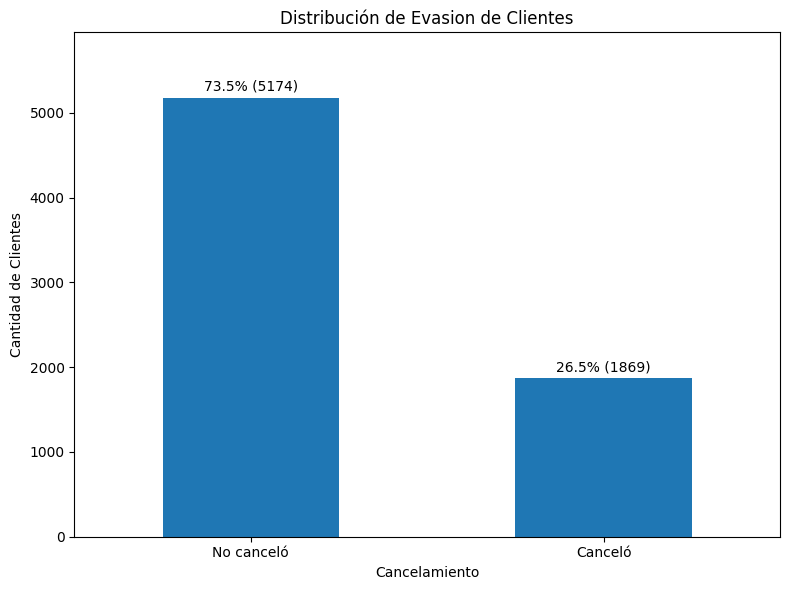

In [55]:
# Distribución de evasión
vector_cancelacion = telecom['Cancelación (churn)'].map({
    True: 'Canceló',
    False: 'No canceló'
}).astype('string')
plt.figure(figsize=(8, 6))

ax = vector_cancelacion.value_counts().plot(kind='bar')
plt.title('Distribución de Evasion de Clientes')
plt.xlabel('Cancelamiento')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)

plt.ylim(0, vector_cancelacion.value_counts().max() * 1.15)

for i, percentage in enumerate((vector_cancelacion.value_counts() / len(vector_cancelacion)) * 100):
    ax.text(i, vector_cancelacion.value_counts().iloc[i] + 50, f'{percentage:.1f}% ({vector_cancelacion.value_counts().iloc[i]})', ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [56]:
# Recuento de evasión por variables categóricas
# En principio, la variable categórica será el género
px.histogram(telecom, x = 'Género', text_auto = True, color = 'Cancelación (churn)', barmode = 'group')


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': 'Cancelación (churn)=False<br>Género=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': 'False',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'False',
              'offsetgroup': 'False',
              'orientation': 'v',
              'showlegend': True,
              'texttemplate': '%{value}',
              'type': 'histogram',
              'x': array(['Femenino', 'Masculino', 'Femenino', ..., 'Masculino', 'Masculino',
                          'Masculino'], shape=(5174,), dtype=object),
              'xaxis': 'x',
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': 'Cancelación (churn)=True<br>Género=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': 'True',
              'marker': {'color': '#EF553B', 'pattern': {'shape': ''}},
              'name': 'True',
              'offsetgroup': 'True',
              'orientation': 'v',
              'showlegend': True,
              'texttemplate': '%{value}',
              'type': 'histogram',
              'x': array(['Masculino', 'Masculino', 'Femenino', ..., 'Femenino', 'Femenino',
                          'Masculino'], shape=(1869,), dtype=object),
              'xaxis': 'x',
              'yaxis': 'y'}],
    'layout': {'barmode': 'group',
               'legend': {'title': {'text': 'Cancelación (churn)'}, 'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Género'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'count'}}}
})

In [57]:
# Ahora el recuento será por el tipo de contrato
px.histogram(telecom, x = 'Tipo de contrato', text_auto = True, color = 'Cancelación (churn)', barmode = 'group')


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': 'Cancelación (churn)=False<br>Tipo de contrato=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': 'False',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'False',
              'offsetgroup': 'False',
              'orientation': 'v',
              'showlegend': True,
              'texttemplate': '%{value}',
              'type': 'histogram',
              'x': array(['Un año', 'Mes a mes', 'Mes a mes', ..., 'Mes a mes', 'Dos años',
                          'Dos años'], shape=(5174,), dtype=object),
              'xaxis': 'x',
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': 'Cancelación (churn)=True<br>Tipo de contrato=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': 'True',
              'marker': {'color': '#EF553B', 'pattern': {'shape': ''}},
              'name': 'True',
              'offsetgroup': 'True',
              'orientation': 'v',
              'showlegend': True,
              'texttemplate': '%{value}',
              'type': 'histogram',
              'x': array(['Mes a mes', 'Mes a mes', 'Mes a mes', ..., 'Mes a mes', 'Mes a mes',
                          'Mes a mes'], shape=(1869,), dtype=object),
              'xaxis': 'x',
              'yaxis': 'y'}],
    'layout': {'barmode': 'group',
               'legend': {'title': {'text': 'Cancelación (churn)'}, 'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Tipo de contrato'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'count'}}}
})

In [58]:
# Ahora según el método de pago
px.histogram(telecom, x = 'Método de pago', text_auto = True, color = 'Cancelación (churn)', barmode = 'group')


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': 'Cancelación (churn)=False<br>Método de pago=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': 'False',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'False',
              'offsetgroup': 'False',
              'orientation': 'v',
              'showlegend': True,
              'texttemplate': '%{value}',
              'type': 'histogram',
              'x': array(['Cheque enviado por correo', 'Cheque enviado por correo',
                          'Tarjeta de crédito (automático)', ..., 'Cheque enviado por correo',
                          'Cheque enviado por correo', 'Cheque electrónico'],
                         shape=(5174,), dtype=object),
              'xaxis': 'x',
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': 'Cancelación (churn)=True<br>Método de pago=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': 'True',
              'marker': {'color': '#EF553B', 'pattern': {'shape': ''}},
              'name': 'True',
              'offsetgroup': 'True',
              'orientation': 'v',
              'showlegend': True,
              'texttemplate': '%{value}',
              'type': 'histogram',
              'x': array(['Cheque electrónico', 'Cheque electrónico', 'Cheque enviado por correo',
                          ..., 'Cheque enviado por correo', 'Transferencia bancaria (automático)',
                          'Cheque electrónico'], shape=(1869,), dtype=object),
              'xaxis': 'x',
              'yaxis': 'y'}],
    'layout': {'barmode': 'group',
               'legend': {'title': {'text': 'Cancelación (churn)'}, 'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Método de pago'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'count'}}}
})

In [59]:
# Según la antigüedad
px.histogram(telecom, x = 'Antigüedad (meses)', text_auto = True, color = 'Cancelación (churn)', barmode = 'group')


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': ('Cancelación (churn)=False<br>A' ... '}<br>count=%{y}<extra></extra>'),
              'legendgroup': 'False',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'False',
              'offsetgroup': 'False',
              'orientation': 'v',
              'showlegend': True,
              'texttemplate': '%{value}',
              'type': 'histogram',
              'x': {'bdata': ('CQkJRz8HQTZIBUg4RyIBMhcDNzYaRS' ... 'UGSEcBRxM/BiJDHDVALgEvBw0CQz8='),
                    'dtype': 'i1'},
              'xaxis': 'x',
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': 'Cancelación (churn)=True<br>Antigüedad (meses)=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': 'True',
              'marker': {'color': '#EF553B', 'pattern': {'shape': ''}},
              'name': 'True',
              'offsetgroup': 'True',
              'orientation': 'v',
              'showlegend': True,
              'texttemplate': '%{value}',
              'type': 'histogram',
              'x': {'bdata': ('BA0DLQENBAECKAsBATEVJQcPAgwBAx' ... 'kjExECAQgBAygBGg4JAQMPJhUJAQQW'),
                    'dtype': 'i1'},
              'xaxis': 'x',
              'yaxis': 'y'}],
    'layout': {'barmode': 'group',
               'legend': {'title': {'text': 'Cancelación (churn)'}, 'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Antigüedad (meses)'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'count'}}}
})

In [60]:
# Según la edad
px.histogram(telecom, x = 'Jubilado (+60 años)', text_auto = True, color = 'Cancelación (churn)', barmode = 'group')


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': ('Cancelación (churn)=False<br>J' ... '}<br>count=%{y}<extra></extra>'),
              'legendgroup': 'False',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'False',
              'offsetgroup': 'False',
              'orientation': 'v',
              'showlegend': True,
              'texttemplate': '%{value}',
              'type': 'histogram',
              'x': array([False, False, False, ..., False, False, False],
                         shape=(5174,), dtype=object),
              'xaxis': 'x',
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': ('Cancelación (churn)=True<br>Ju' ... '}<br>count=%{y}<extra></extra>'),
              'legendgroup': 'True',
              'marker': {'color': '#EF553B', 'pattern': {'shape': ''}},
              'name': 'True',
              'offsetgroup': 'True',
              'orientation': 'v',
              'showlegend': True,
              'texttemplate': '%{value}',
              'type': 'histogram',
              'x': array([False, True, True, ..., False, False, False],
                         shape=(1869,), dtype=object),
              'xaxis': 'x',
              'yaxis': 'y'}],
    'layout': {'barmode': 'group',
               'legend': {'title': {'text': 'Cancelación (churn)'}, 'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Jubilado (+60 años)'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'count'}}}
})

In [61]:
# Y según el tipo de servicio de internet con el que se cuente
px.histogram(telecom, x = 'Servicio de internet', text_auto = True, color = 'Cancelación (churn)', barmode = 'group')


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': ('Cancelación (churn)=False<br>S' ... '}<br>count=%{y}<extra></extra>'),
              'legendgroup': 'False',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'False',
              'offsetgroup': 'False',
              'orientation': 'v',
              'showlegend': True,
              'texttemplate': '%{value}',
              'type': 'histogram',
              'x': array(['DSL', 'DSL', 'DSL', ..., 'DSL', 'DSL', 'DSL'],
                         shape=(5174,), dtype=object),
              'xaxis': 'x',
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': ('Cancelación (churn)=True<br>Se' ... '}<br>count=%{y}<extra></extra>'),
              'legendgroup': 'True',
              'marker': {'color': '#EF553B', 'pattern': {'shape': ''}},
              'name': 'True',
              'offsetgroup': 'True',
              'orientation': 'v',
              'showlegend': True,
              'texttemplate': '%{value}',
              'type': 'histogram',
              'x': array(['Fibra óptica', 'Fibra óptica', 'Fibra óptica', ..., 'Fibra óptica',
                          'No', 'Fibra óptica'], shape=(1869,), dtype=object),
              'xaxis': 'x',
              'yaxis': 'y'}],
    'layout': {'barmode': 'group',
               'legend': {'title': {'text': 'Cancelación (churn)'}, 'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Servicio de internet'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'count'}}}
})

In [62]:
# Conteo de evasión (cancelación/churn) por costos de servicio por mes

fig1 = px.histogram(telecom, x='Cuentas mensuales', color='Cancelación (churn)', barmode='group',
                   title='Distribución de cancelación por costos mensuales', text_auto=True)
fig1.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': 'Cancelación (churn)=False<br>Cuentas mensuales=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': 'False',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'False',
              'offsetgroup': 'False',
              'orientation': 'v',
              'showlegend': True,
              'texttemplate': '%{value}',
              'type': 'histogram',
              'x': {'bdata': ('ZmZmZmZmUEAzMzMzM/NNQJqZmZmZWV' ... 'ZmJklAZmZmZmb2UEAAAAAAAIBNQA=='),
                    'dtype': 'f8'},
              'xaxis': 'x',
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': 'Cancelación (churn)=True<br>Cuentas mensuales=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': 'True',
              'marker': {'color': '#EF553B', 'pattern': {'shape': ''}},
              'name': 'True',
              'offsetgroup': 'True',
              'orientation': 'v',
              'showlegend': True,
              'texttemplate': '%{value}',
              'type': 'histogram',
              'x': {'bdata': ('mpmZmZl5UkAAAAAAAIBYQJqZmZmZ+V' ... 'mZmZmJUUAzMzMzM/M0QGZmZmZmRlVA'),
                    'dtype': 'f8'},
              'xaxis': 'x',
              'yaxis': 'y'}],
    'layout': {'barmode': 'group',
               'legend': {'title': {'text': 'Cancelación (churn)'}, 'tracegroupgap': 0},
               'template': '...',
               'title': {'text': 'Distribución de cancelación por costos mensuales'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Cuentas mensuales'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'count'}}}
})

In [63]:
# Conteo de evasión por cobro total
fig2 = px.histogram(telecom, x='Cobro total', color='Cancelación (churn)', barmode='group',
                   title='Distribución de Cancelación por Cobro Total', text_auto=True)
fig2.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': 'Cancelación (churn)=False<br>Cobro total=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': 'False',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'False',
              'offsetgroup': 'False',
              'orientation': 'v',
              'showlegend': True,
              'texttemplate': '%{value}',
              'type': 'histogram',
              'x': {'bdata': ('ZmZmZmaKgkAzMzMzM/OAQJqZmZmZ24' ... 'AAMFdAZmZmZqYTskAzMzMzM/esQA=='),
                    'dtype': 'f8'},
              'xaxis': 'x',
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'bingroup': 'x',
              'hovertemplate': 'Cancelación (churn)=True<br>Cobro total=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': 'True',
              'marker': {'color': '#EF553B', 'pattern': {'shape': ''}},
              'name': 'True',
              'offsetgroup': 'True',
              'orientation': 'v',
              'showlegend': True,
              'texttemplate': '%{value}',
              'type': 'histogram',
              'x': {'bdata': ('mpmZmZmNcUBmZmZmZleTQGZmZmZmtn' ... 'mZmZmJUUAAAAAAAGBVQM3MzMzMRp1A'),
                    'dtype': 'f8'},
              'xaxis': 'x',
              'yaxis': 'y'}],
    'layout': {'barmode': 'group',
               'legend': {'title': {'text': 'Cancelación (churn)'}, 'tracegroupgap': 0},
               'template': '...',
               'title': {'text': 'Distribución de Cancelación por Cobro Total'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Cobro total'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'count'}}}
})

Informe final
Análisis de evasión de clientes (Churn) - Telecom X

1. Introducción

El objetivo de este análisis es comprender los factores que impulsan la pérdida de clientes en Telecom X. El fenómeno del Churn (evasión) representa uno de los mayores desafíos financieros en el sector de las telecomunicaciones, ya que el costo de adquisición de un nuevo cliente es significativamente superior al de retención. A través de este estudio, buscamos identificar patrones demográficos, de servicio y financieros que permitan al equipo de Data Science desarrollar estrategias preventivas eficaces.

2. Limpieza y tratamiento de datos

El proceso de ETL (Extracción, Transformación y Carga) fue fundamental para asegurar la calidad de la señal analítica:

Extracción: Los datos se obtuvieron en formato JSON, presentando una estructura inicialmente anidada que requería normalización.

Aplanamiento (Flattening): Se "desempaquetaron" los diccionarios internos de las columnas customer, phone, internet y account para crear un dataset plano y manejable.

Tratamiento de inconsistencias: Se eliminaron registros con etiquetas de Abandono vacías (aproximadamente un 3% del total) para evitar ruido en el análisis.

Conversión de tipos: Las columnas financieras (Charges.Monthly, Charges.Total) y de tiempo (tenure) se transformaron de texto a formatos numéricos (float e int) para permitir cálculos matemáticos.

Estandarización: Se tradujeron las columnas al español y se crearon nuevas métricas como Cargo_Diario para aumentar la granularidad del análisis de costos.

3. Análisis exploratorio de datos (EDA)

Mediante la visualización estratégica, se identificaron los siguientes comportamientos:

Distribución del abandono: La tasa de evasión se sitúa en un 26.5%, lo que representa una pérdida crítica de la base instalada.

Análisis por contrato: Los clientes con contratos "Mes a mes" muestran una propensión al abandono drásticamente superior a aquellos con contratos a largo plazo.

Factor antigüedad (tenure): Existe un riesgo de fuga extremadamente alto durante los primeros 6 meses de servicio.

Soporte técnico: La ausencia de suscripción a Soporte Técnico correlaciona positivamente con una mayor tasa de evasión.

4. Conclusiones e insights

Vulnerabilidad inicial: El cliente de Telecom X es más propenso a irse al inicio de la relación contractual, lo que sugiere una falta de "fidelización temprana".

Elasticidad de precio: Los clientes que abandonan presentan cargos mensuales medianamente superiores, indicando que el precio es un detonante de insatisfacción cuando no se acompaña de servicios de valor agregado.

Impacto del soporte: El soporte técnico actúa como un ancla de retención; los clientes que se sienten respaldados técnicamente tienen una vida útil (LTV) más larga en la empresa.

5. Recomendaciones estratégicas

Incentivos a la permanencia: Implementar descuentos o beneficios exclusivos para migrar a los clientes de "Mes a mes" a contratos de "Un año".

Programa de "onboarding": Reforzar la atención y el soporte técnico gratuito durante los primeros 3 meses de contrato para reducir el pico de evasión temprana.

Venta cruzada de seguridad y soporte: Promocionar los servicios de OnlineSecurity y TechSupport en paquetes básicos, ya que estos servicios reducen drásticamente la probabilidad de Churn.

Monitoreo de precios: Establecer alertas automáticas para el equipo de fidelización cuando un cliente alcance un Cargo_Mensual superior al percentil 80 de su segmento.